In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv('../pre-calculated_data/contig_selected.tsv',sep = '\t',header=None,names=['contig','length','cp','sample'])
df

,contig,length,cp,sample
0,cpsnj15_contig_69220,21763,0,cpsnj15
1,sample24_contig_100860,51165,2,sample24
2,snj16_contig_37626,109825,5,snj16
3,sample18_contig_7034,215209,0,sample18
4,sample19_contig_65143,134477,6,sample19
...,...,...,...,...
13690,snj13_contig_71399,81564,4,snj13
13691,sample1_contig_119693,20643,0,sample1
13692,sample27_contig_92478,13513,0,sample27
13693,cpsnj16_contig_11795,12712,0,cpsnj16


In [3]:
sum_value1 = df.groupby('sample')['length'].sum()
sum_value2 = df.groupby('sample')['cp'].sum()
 
ratio = sum_value2/(sum_value1/1000000)
 
result = pd.DataFrame({
    'Sum_length': sum_value1,
    'Sum_cp': sum_value2,
    'Ratio': ratio
})
result['Type'] = 'not plasmid'
result

,Sum_length,Sum_cp,Ratio,Type
sample,,,,
cpsnj01,7114618,235,33.030586,not plasmid
cpsnj02,10527758,298,28.306122,not plasmid
cpsnj03,11294263,276,24.437185,not plasmid
cpsnj04,13739213,381,27.730846,not plasmid
cpsnj08,10786239,345,31.985199,not plasmid
cpsnj09,21167039,632,29.857743,not plasmid
cpsnj10,12874844,330,25.631379,not plasmid
cpsnj11,10250320,280,27.316220,not plasmid
cpsnj13,9340928,297,31.795556,not plasmid


In [4]:
df = pd.read_csv('../pre-calculated_data/contigs_plasmid_all_cpnumber.tsv',sep = '\t',header=None,names=['contig','circ','length','score','tax','sample','cp'])
df

,contig,circ,length,score,tax,sample,cp
0,cpsnj01_contig_62473,linear,21665,0.9939,12 # class # Bacilli,cpsnj01,2
1,cpsnj01_contig_68824,linear,47631,0.9918,96 # family # Rhizobiaceae,cpsnj01,3
2,cpsnj01_contig_56426,linear,26475,0.9918,96 # family # Rhizobiaceae,cpsnj01,3
3,cpsnj01_contig_60924,linear,78135,0.9899,96 # family # Rhizobiaceae,cpsnj01,2
4,cpsnj01_contig_75747,linear,14166,0.9892,25709 # genus # Microvirga,cpsnj01,3
...,...,...,...,...,...,...,...
13690,snj20_contig_12899,linear,16232,0.9504,90 # class # Alphaproteobacteria,snj20,0
13691,snj20_contig_79001,linear,30226,0.9502,3 # phylum # Pseudomonadota,snj20,0
13692,snj20_contig_3784,linear,70089,0.9502,66 # family # Burkholderiaceae,snj20,0
13693,snj20_contig_61622,linear,21792,0.9502,56 # order # Burkholderiales,snj20,1


In [5]:
sum_value1 = df.groupby('sample')['length'].sum()
sum_value2 = df.groupby('sample')['cp'].sum()
 
ratio = sum_value2/(sum_value1/1000000)
 
result_plasmid = pd.DataFrame({
    'Sum_length': sum_value1,
    'Sum_cp': sum_value2,
    'Ratio': ratio
})
result_plasmid['Type'] = 'plasmid'
result_plasmid

,Sum_length,Sum_cp,Ratio,Type
sample,,,,
cpsnj01,14659413,778,53.071702,plasmid
cpsnj02,7173492,325,45.305689,plasmid
cpsnj03,5214557,223,42.764898,plasmid
cpsnj04,9467308,318,33.589274,plasmid
cpsnj08,9944002,541,54.404655,plasmid
cpsnj09,9066342,530,58.457976,plasmid
cpsnj10,11845199,760,64.161016,plasmid
cpsnj11,11038668,465,42.124648,plasmid
cpsnj13,7121898,390,54.760683,plasmid


In [6]:
result_all = pd.concat([result,result_plasmid])
result_all

,Sum_length,Sum_cp,Ratio,Type
sample,,,,
cpsnj01,7114618,235,33.030586,not plasmid
cpsnj02,10527758,298,28.306122,not plasmid
cpsnj03,11294263,276,24.437185,not plasmid
cpsnj04,13739213,381,27.730846,not plasmid
cpsnj08,10786239,345,31.985199,not plasmid
...,...,...,...,...
snj14,8492859,429,50.513025,plasmid
snj15,6420955,242,37.689098,plasmid
snj16,7391498,309,41.804787,plasmid


In [7]:
import scipy.stats as stats
bacteria = result['Ratio'].tolist()
plasmid = result_plasmid['Ratio'].tolist()
statistic,pvalue=stats.mannwhitneyu(bacteria,plasmid,alternative = 'two-sided')
pvalue

1.1704099218478365e-17

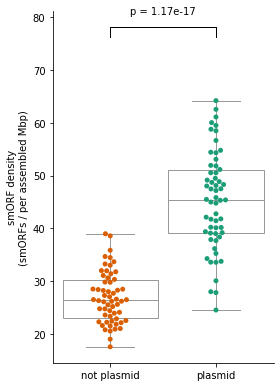

In [8]:
fig = plt.figure(figsize=(4, 5.5))
colors= ['#d95f02','#1b9e77']
sns.set_palette(sns.color_palette(colors))

ax=sns.boxplot(
            data=result_all,
            x='Type',
            y='Ratio',
            showfliers=False,
            color='white',width=0.9)

sns.swarmplot(
              data=result_all,
              x='Type',
              y='Ratio',
              s=5,
              hue='Type' 
              )

x1, x2 = 0, 1
y,h = result_all["Ratio"].mean()+40,2

#绘制横线位置
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 
#添加P值
plt.text((x1+x2)*.5, y+h+2, 'p = 1.17e-17', ha='center', va='bottom', color="k")
#plt.legend(loc=3,bbox_to_anchor=(0,1.1),ncol=2)

#plt.ylim([0,400])
ax.set_xlabel('')
ax.set_ylabel('smORF density\n(smORFs / per assembled Mbp)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()